# Notebook 06: Temporal Difference Learning

**Series:** Reinforcement Learning Basics (6/20)

---

## 1. TD Learning: The Best of Both Worlds

TD combines **MC** (learn from experience, no model) with **DP** (bootstrap, update before episode ends).

### TD(0) Update Rule

$$\boxed{V(S_t) \leftarrow V(S_t) + \alpha \Big[ \underbrace{R_{t+1} + \gamma V(S_{t+1})}_{\text{TD Target}} - V(S_t) \Big]}$$

| Term | Name | Meaning |
|------|------|---------|
| $R_{t+1} + \gamma V(S_{t+1})$ | **TD Target** | Estimated return |
| $\delta_t = R_{t+1} + \gamma V(S_{t+1}) - V(S_t)$ | **TD Error** | How wrong our estimate was |
| $\alpha$ | **Learning rate** | Step size |

### Why TD?
- Can learn **online** (after every step, not just episode end)
- Can learn from **incomplete** sequences
- Works for **continuing** tasks (no episodes needed)
- **Lower variance** than MC (bootstrapping reduces variance)

## 2. Bias-Variance Tradeoff

| Method | Target | Bias | Variance |
|--------|--------|------|----------|
| **MC** | $G_t$ (actual return) | **Zero** bias | **High** variance |
| **TD(0)** | $R_{t+1} + \gamma V(S_{t+1})$ | **Some** bias (depends on $V$) | **Lower** variance |

**Why MC has high variance:** $G_t$ depends on many random actions, transitions, and rewards over the entire episode.

**Why TD has lower variance:** Only depends on one random action, transition, and reward (one step).

**Why TD has bias:** We use our current estimate $V(S_{t+1})$ instead of the true value — if $V$ is wrong, the target is biased.

## 3. Batch TD vs Batch MC

Given a finite batch of episodes, TD and MC converge to different answers:

- **Batch MC:** Minimizes mean-squared error on training data
- **Batch TD:** Finds the maximum likelihood MDP model, then solves it (**certainty equivalence**)

TD exploits the Markov property and is usually more data-efficient.

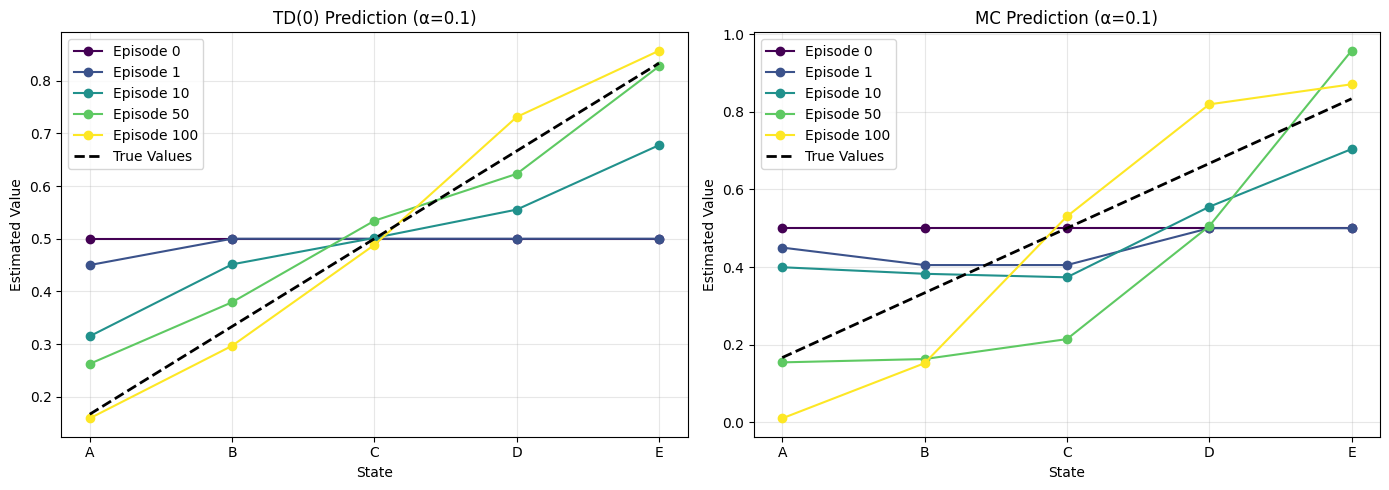

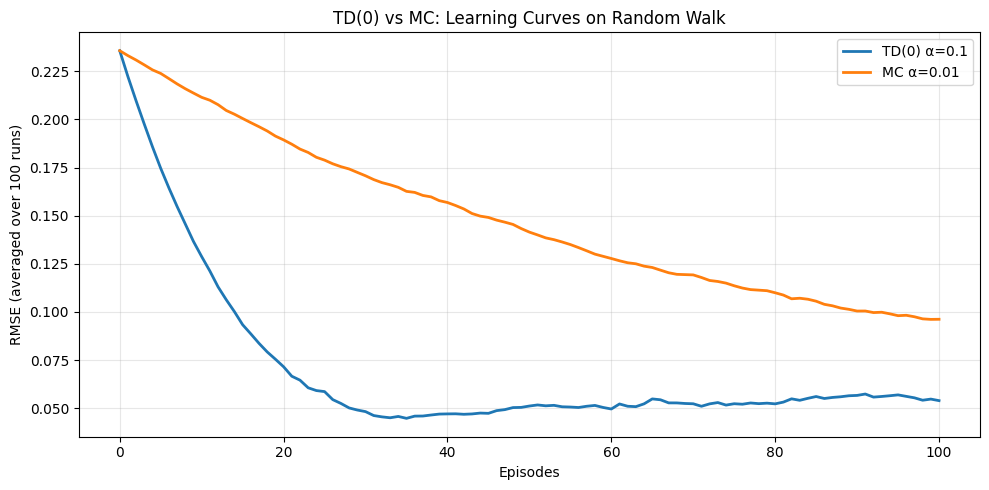

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================
# Random Walk Environment (5 states)
# ============================================
# States: 0(terminal-left), 1, 2, 3, 4, 5, 6(terminal-right)
# Start in state 3 (center)
# Actions: left (-1) or right (+1) with equal probability
# Reward: +1 at right terminal, 0 everywhere else

TRUE_VALUES = np.array([0, 1/6, 2/6, 3/6, 4/6, 5/6, 0])  # including terminals

def td0_prediction(n_episodes=100, alpha=0.1, gamma=1.0):
    V = np.full(7, 0.5)
    V[0] = 0; V[6] = 0  # terminal states
    history = [V[1:6].copy()]

    for _ in range(n_episodes):
        state = 3  # start in center
        while state not in [0, 6]:
            action = np.random.choice([-1, 1])
            next_state = state + action
            reward = 1.0 if next_state == 6 else 0.0
            # TD(0) update
            V[state] += alpha * (reward + gamma * V[next_state] - V[state])
            state = next_state
        history.append(V[1:6].copy())
    return V, history

def mc_prediction(n_episodes=100, alpha=0.1, gamma=1.0):
    V = np.full(7, 0.5)
    V[0] = 0; V[6] = 0
    history = [V[1:6].copy()]

    for _ in range(n_episodes):
        state = 3
        trajectory = [state]
        while state not in [0, 6]:
            action = np.random.choice([-1, 1])
            state = state + action
            trajectory.append(state)

        # Return: 1 if ended at right terminal, 0 otherwise
        G = 1.0 if trajectory[-1] == 6 else 0.0

        # Update all visited states
        for s in trajectory[:-1]:
            V[s] += alpha * (G - V[s])
        history.append(V[1:6].copy())
    return V, history

# Run both
np.random.seed(42)
V_td, td_hist = td0_prediction(n_episodes=100, alpha=0.1)
np.random.seed(42)
V_mc, mc_hist = mc_prediction(n_episodes=100, alpha=0.1)

# Plot learned values at different episodes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
episodes_to_show = [0, 1, 10, 50, 100]
colors = plt.cm.viridis(np.linspace(0, 1, len(episodes_to_show)))

for ax, hist, title in [(axes[0], td_hist, 'TD(0)'), (axes[1], mc_hist, 'MC')]:
    for i, ep in enumerate(episodes_to_show):
        if ep < len(hist):
            ax.plot(range(1, 6), hist[ep], 'o-', color=colors[i], label=f'Episode {ep}')
    ax.plot(range(1, 6), TRUE_VALUES[1:6], 'k--', linewidth=2, label='True Values')
    ax.set_xlabel('State')
    ax.set_ylabel('Estimated Value')
    ax.set_title(f'{title} Prediction (α=0.1)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xticks(range(1, 6))
    ax.set_xticklabels(['A', 'B', 'C', 'D', 'E'])

plt.tight_layout()
plt.show()

# RMSE comparison
n_runs = 100
n_episodes = 100
rmse_td = np.zeros(n_episodes + 1)
rmse_mc = np.zeros(n_episodes + 1)

for run in range(n_runs):
    _, td_h = td0_prediction(n_episodes, alpha=0.1)
    _, mc_h = mc_prediction(n_episodes, alpha=0.01)
    for ep in range(min(len(td_h), n_episodes + 1)):
        rmse_td[ep] += np.sqrt(np.mean((td_h[ep] - TRUE_VALUES[1:6])**2))
    for ep in range(min(len(mc_h), n_episodes + 1)):
        rmse_mc[ep] += np.sqrt(np.mean((mc_h[ep] - TRUE_VALUES[1:6])**2))

rmse_td /= n_runs
rmse_mc /= n_runs

plt.figure(figsize=(10, 5))
plt.plot(rmse_td, label='TD(0) α=0.1', linewidth=2)
plt.plot(rmse_mc, label='MC α=0.01', linewidth=2)
plt.xlabel('Episodes')
plt.ylabel('RMSE (averaged over 100 runs)')
plt.title('TD(0) vs MC: Learning Curves on Random Walk')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Summary

| Property | MC | TD(0) |
|----------|----| ------|
| **Target** | $G_t$ (actual return) | $R_{t+1} + \gamma V(S_{t+1})$ |
| **Bias** | None | Some (bootstrapping) |
| **Variance** | High | Lower |
| **Model needed** | No | No |
| **Complete episodes** | Yes | **No** |
| **Bootstrapping** | No | **Yes** |

**Next:** Notebook 07 — SARSA